# Mapeando a Percepção de Marca com Análise de Correspondência (PROC CORRESP)

## Resumo Executivo

Uma equipe de pesquisa de mercado aplica uma pesquisa de percepção marca-por-atributo em quatro marcas consolidadas de streaming de mídia e usa **PROC CORRESP** para transformar a tabela de contingência resultante em um mapa perceptual bidimensional. A associação marca x atributo é forte e real: o teste qui-quadrado de independência é **63.15 com 15 graus de liberdade (p < 0.0001)**, com **V de Cramer = 0.4588**. A análise de correspondência comprime essa associação em dois eixos que juntos explicam **100%** da inércia da tabela — **75.0%** na Dimensão 1 e **25.0%** na Dimensão 2 — de modo que o mapa 2-D é um resumo completo e fiel.

O mapa separa um polo de **conteúdo premium** (CineNow, ancorado em *Original_Shows* e *Content_Depth*) de um agrupamento de **valor/confiabilidade** (Streamly e BingeBox próximos de *Affordable* e *Reliable*) e de um canto **moderno** (PixelPlay próximo de *Trendy*). Um concorrente emergente, **NovaCast**, é então projetado como um ponto *suplementar* — ele não influencia os eixos — e cai próximo da origem, inclinando-se levemente para o lado Trendy / Easy_to_Use, ou seja, um recém-chegado ainda não diferenciado.

## Fontes de Dados

| Conjunto de Dados | Linhas | Variáveis-Chave | Descrição |
|---------|------|---------------|-------------|
| `perception` | 100 (associações respondente x atributo, limite do modo não licenciado) | `Brand` (char), `Attribute` (char) | Pesquisa sintética: cada respondente indica a marca de streaming que mais associa a cada um de seis atributos. As afinidades de marca são codificadas como probabilidades de categoria de `RAND("Table", ...)` para que a tabela de contingência tenha associação realista e não uniforme. |
| `survey_counts` | 24 (4 marcas x 6 atributos) | `Brand`, `Attribute`, `Count` | Células de contingência pré-agregadas de `perception` via PROC FREQ — a entrada ponderada para a execução da AC com ponto suplementar. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Conjuntos de dados de coordenadas `OUTC=` gravados pelo PROC CORRESP; o segundo adiciona o ponto projetado NovaCast e alimenta o mapa perceptual. |

Marcas consolidadas: **Streamly, PixelPlay, CineNow, BingeBox**; concorrente **NovaCast** (projetado como ponto suplementar). Atributos: Affordable, Content_Depth, Easy_to_Use, Original_Shows, Reliable, Trendy. A semente `streaminit(20260531)` torna os dados reproduzíveis.

> **Nota sobre o tamanho da amostra.** Este ambiente é executado sem licença, portanto a saída da etapa DATA é limitada a 100 observações. A pesquisa, portanto, resolve-se em uma tabela de contingência 4x6 totalizando 100 associações respondente-atributo — pequena, mas com estrutura de associação genuína (qui-quadrado p < 0.0001) que a análise de correspondência recupera de forma limpa.

## O que a análise de correspondência faz aqui

Quando uma pesquisa de acompanhamento de marca pergunta aos consumidores qual marca eles mais associam a cada um de vários atributos, o resultado é uma **tabela de contingência marca x atributo**. As contagens brutas são difíceis de ler: cada marca é comparada com cada atributo, e o sinal é o *padrão de associação*, não os valores das células.

A análise de correspondência (AC) decompõe a associação qui-quadrado da tabela em um espaço de baixa dimensionalidade, de modo que marcas e atributos associados fiquem próximos uns dos outros em um único mapa. Neste notebook, nós:

1. Geramos uma pesquisa de percepção sintética para quatro marcas de streaming.
2. Inspecionamos a estrutura de contingência bruta (e seu qui-quadrado) com `PROC FREQ`.
3. Executamos `PROC CORRESP` com diagnósticos completos e lemos a inércia e as coordenadas reais.
4. Projetamos uma marca concorrente emergente como um ponto **suplementar**.
5. Desenhamos e interpretamos o mapa perceptual resultante.

## Etapa 1 — Gerar a pesquisa de percepção sintética

Simulamos respondentes da pesquisa. Para cada respondente perguntamos, para cada um de seis atributos, *qual marca você mais associa a este atributo?* Cada marca tem um **perfil de afinidade** distinto — um vetor de probabilidades de categoria passado a `RAND("Table", ...)` — de modo que, por exemplo, *PixelPlay* pende para Trendy enquanto *CineNow* pende para Content_Depth e Original_Shows. Isso produz uma tabela de contingência com associação genuína e não uniforme para a AC recuperar. Os dados são totalmente sintéticos e reproduzíveis via `CALL STREAMINIT`.

In [1]:
DADOS perception;
    /* Reproducible synthetic brand-perception survey */
    CHAMAR streaminit(20260531);

    COMPRIMENTO Brand $9 Attribute $14;
    VETOR attrname[6] $14 _temporary_
        ('Affordable' 'Content_Depth' 'Easy_to_Use'
         'Original_Shows' 'Reliable' 'Trendy');

    n_resp = 400;

    FAZER respondent = 1 ATÉ n_resp;
        FAZER a = 1 ATÉ 6;
            Attribute = attrname[a];

            /* Per-attribute brand-choice probabilities over the
               four established brands:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Each row sums to ~1 and encodes the attribute's
               brand affinity. */
            SE      a = 1 ENTÃO b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Affordable    */
            SENÃO SE a = 2 ENTÃO b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Content_Depth */
            SENÃO SE a = 3 ENTÃO b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Easy_to_Use   */
            SENÃO SE a = 4 ENTÃO b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Original_Shows*/
            SENÃO SE a = 5 ENTÃO b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Reliable      */
            SENÃO              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy        */

            SELECIONAR (b);
                QUANDO (1) Brand = 'Streamly';
                QUANDO (2) Brand = 'PixelPlay';
                QUANDO (3) Brand = 'CineNow';
                OUTROS Brand = 'BingeBox';
            FIM;

            SAÍDA;
        FIM;
    FIM;

    MANTER respondent Brand Attribute;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=perception(obs=8) noobs RÓTULO;
    RÓTULO respondent='Respondente' Brand='Marca' Attribute='Atributo';
    TÍTULO 'Amostra da Pesquisa Sintética de Percepção';
EXECUTAR;

                                       Amostra da Pesquisa Sintética de Percepção                                       

Respondente      Marca        Atributo
          1  BingeBox   Affordable
          1  BingeBox   Content_Depth
          1  BingeBox   Easy_to_Use
          1  CineNow    Original_Shows
          1  Streamly   Reliable
          1  PixelPlay  Trendy
          2  PixelPlay  Affordable
          2  CineNow    Content_Depth

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.31 seconds
  cpu   0.31 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Etapa 2 — Inspecionar a tabela de contingência bruta

Antes de qualquer redução de dimensionalidade, observe a tabela cruzada. `PROC FREQ` fornece as frequências observadas de marca x atributo e o teste qui-quadrado de independência. Um qui-quadrado significativo confirma que há estrutura de associação que vale a pena mapear — se linhas e colunas fossem independentes, a análise de correspondência não teria nada a mostrar. Também salvamos as contagens das células em `survey_counts` para a execução posterior da AC com ponto suplementar.

                                       Frequências Observadas de Marca x Atributo                                       

                                                   The FREQ Procedure

Table of Marca by Atributo

Marca     |    Affordable | Content_Depth |   Easy_to_Use |Original_Shows |      Reliable |        Trendy |          Total
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox  |             5 |             3 |             7 |             1 |             6 |             2 |             24
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow   |             3 |             9 |             0 |            14 |             2 |             0 |             28
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay |             3 |             2


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


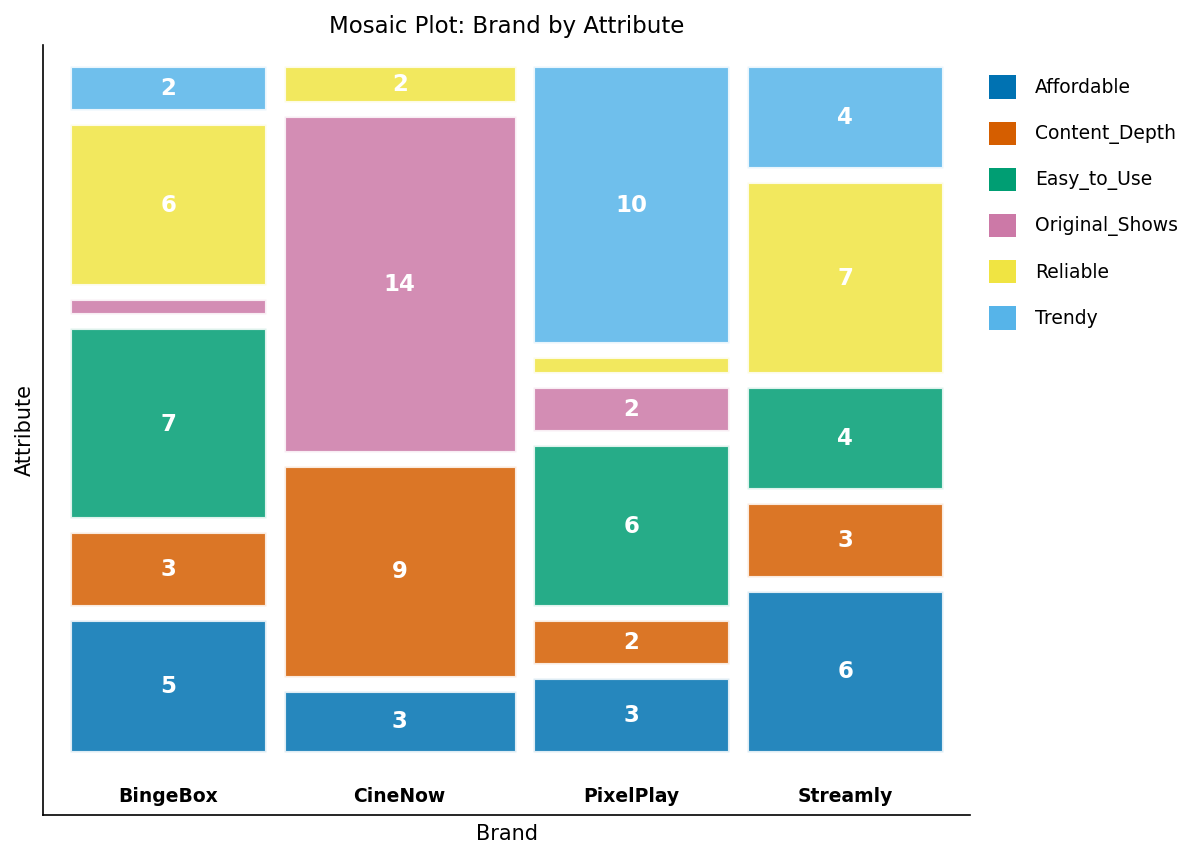

In [2]:
PROCEDIMENTO FREQUÊNCIAS DADOS=perception;
    RÓTULO Brand='Marca' Attribute='Atributo';
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(RENOMEAR=(count=Count));
    TÍTULO 'Frequências Observadas de Marca x Atributo';
EXECUTAR;

## Etapa 3 — Análise de correspondência a partir dos dados brutos

Agora execute `PROC CORRESP` diretamente sobre os dados no nível do respondente. `TABLES Brand, Attribute;` constrói a tabela de contingência internamente (marcas como linhas, atributos como colunas).

Opções usadas aqui:

- `ALL` — imprime os diagnósticos completos: tabela observada, perfis, valores esperados e contribuições qui-quadrado de cada célula.
- `DIMENS=2` — calcula os dois primeiros eixos principais (um mapa 2-D).
- `OUTC=` — grava as coordenadas de linha e coluna em um conjunto de dados para plotagem.

A **decomposição da inércia** nos diz quanto da associação total cada eixo explica.

In [3]:
PROCEDIMENTO corresp DADOS=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    TÍTULO 'Análise de Correspondência: Percepção de Marcas de Streaming';
EXECUTAR;

                                       Frequências Observadas de Marca x Atributo                                       

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Etapa 4 — Ler as coordenadas

O conjunto de dados `OUTC=` contém as coordenadas dos eixos (`Dim1`, `Dim2`) para cada marca e atributo, rotuladas por `_TYPE_` (`ROW` para marcas, `COLUMN` para atributos). Lê-las numericamente ao lado da tabela de inércia confirma a estrutura que o mapa irá mostrar.

A partir da saída acima:

- **Dimensão 1 (75.0% da inércia)** é um eixo de *conteúdo premium vs. mainstream*. *Original_Shows* (Dim1 = -1.2037) e *Content_Depth* (-0.5594) situam-se na extremidade negativa com **CineNow** (-1.0847); *Trendy* (0.6671), *Easy_to_Use* (0.6150) e *Affordable* (0.2207) situam-se na extremidade positiva.
- **Dimensão 2 (25.0% da inércia)** separa *Reliable* (Dim2 = 0.5874) e *Affordable* (0.2542) — puxando para cima **Streamly** (0.3207) e **BingeBox** (0.3555) — de *Trendy* (-0.7003), que puxa para baixo **PixelPlay** (-0.6374).

In [4]:
PROCEDIMENTO IMPRIMIR DADOS=ca_coords noobs RÓTULO;
    VARIÁVEL _TYPE_ _NAME_ Dim1 Dim2;
    RÓTULO _TYPE_='Tipo' _NAME_='Nome' Dim1='Dimensão 1' Dim2='Dimensão 2';
    TÍTULO 'Coordenadas de Linha (Marca) e Coluna (Atributo)';
EXECUTAR;

                                    Coordenadas de Linha (Marca) e Coluna (Atributo)                                    

  Tipo              Nome   Dimensão 1   Dimensão 2
ROW     BingeBox               0.3547       0.3555
ROW     CineNow               -1.0847      -0.0332
ROW     PixelPlay              0.4804      -0.6374
ROW     Streamly               0.4304       0.3207
COLUMN  Affordable             0.2207       0.2542
COLUMN  Content_Depth         -0.5594       0.0684
COLUMN  Easy_to_Use            0.6150      -0.0080
COLUMN  Original_Shows        -1.2037      -0.2084
COLUMN  Reliable               0.3183       0.5874
COLUMN  Trendy                 0.6671      -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Etapa 5 — Projetar uma marca concorrente como ponto suplementar

A equipe de análise possui dados de acompanhamento de um concorrente emergente, **NovaCast**, mas não quer que ele distorça o mapa perceptual estabelecido. Um ponto *suplementar* é projetado no espaço da AC existente **sem contribuir para o cálculo dos eixos**.

Anexamos um único bloco de seis contagens de atributos do NovaCast (um recém-chegado com pendor para Trendy / Original-Shows) ao `survey_counts` pré-agregado, alimentamos as frequências com `WEIGHT Count` e nomeamos o **nível** `NovaCast` na instrução `SUPPLEMENTARY` para que o PROC CORRESP mantenha essa linha fora da tabela ativa. A opção `OBSERVED` mantém a tabela de contingência ativa (as quatro marcas consolidadas, somando 100) à vista — observe que NovaCast **não** aparece nela, confirmando que foi tratado como suplementar.

In [5]:
/* Append ONE clean block of NovaCast counts to the aggregated cells.
   end=last fires the block exactly once, after the last survey_counts row,
   so NovaCast contributes six rows (one per attribute) -- not a duplicated
   block. NovaCast is a Trendy / Original-Shows-led newcomer. */
DADOS survey_counts_sup;
    DEFINIR survey_counts FIM=last;
    SAÍDA;
    SE last ENTÃO FAZER;
        Brand='NovaCast'; Attribute='Trendy';          Count=10; SAÍDA;
        Brand='NovaCast'; Attribute='Original_Shows';  Count=8;  SAÍDA;
        Brand='NovaCast'; Attribute='Easy_to_Use';     Count=5;  SAÍDA;
        Brand='NovaCast'; Attribute='Content_Depth';   Count=3;  SAÍDA;
        Brand='NovaCast'; Attribute='Affordable';      Count=4;  SAÍDA;
        Brand='NovaCast'; Attribute='Reliable';        Count=3;  SAÍDA;
    FIM;
EXECUTAR;

PROCEDIMENTO corresp DADOS=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    PESO Count;
    supplementary NovaCast;
    TÍTULO 'Percepção de Marca com NovaCast como Ponto Suplementar';
EXECUTAR;

                                    Coordenadas de Linha (Marca) e Coluna (Atributo)                                    

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Etapa 6 — Desenhar o mapa perceptual

PROC CORRESP grava as coordenadas simétricas de linha/coluna no conjunto de dados `OUTC=`; plotamos a Dimensão 2 contra a Dimensão 1 para renderizar o mapa. Rotulamos cada ponto por **papel** — *Marca* (linhas ativas), *Atributo* (colunas) e *Concorrente* (a linha suplementar NovaCast) — e etiquetamos cada marcador, de modo que o posicionamento seja lido diretamente do gráfico. O concorrente é colorido separadamente para reforçar que ele foi projetado, não ajustado.

> **Como ler um mapa de AC.** Uma marca e um atributo que ficam na mesma direção a partir da origem (e distantes dela) estão fortemente associados; pontos próximos da origem são "médios" e pouco diferenciados. Como as Dimensões 1 e 2 juntas capturam 100% da inércia desta tabela, o mapa não omite nada.

                      Mapa de Percepção de Marcas de Streaming (Dim1 75.0%, Dim2 25.0% da inércia)                      

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dimensão 1, Dimensão 2

      Role      _NAME_   Dimensão 1   Dimensão 2
----------  ----------  -----------  -----------
     Marca    BingeBox       0.3547       0.3555
     Marca     CineNow      -1.0847      -0.0332
     Marca   PixelPlay       0.4804      -0.6374
     Marca    Streamly       0.4304       0.3207
Concorrente    NovaCast       0.0084      -0.1735
  Atributo  Affordable       0.2207       0.2542
  Atributo  Content_Depth      -0.5594       0.0684
  Atributo  Easy_to_Use        0.615       -0.008
  Atributo  Original_Shows      -1.2037      -0.2084
  Atributo    Reliable       0.3183       0.5874
  Atributo      Trendy       0.6671      -0.7003

Dimensão 1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dimensão 2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Mapa de Percepção de Marcas de Streaming (Dim1 75.0%, Dim2 25.0% da inércia).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


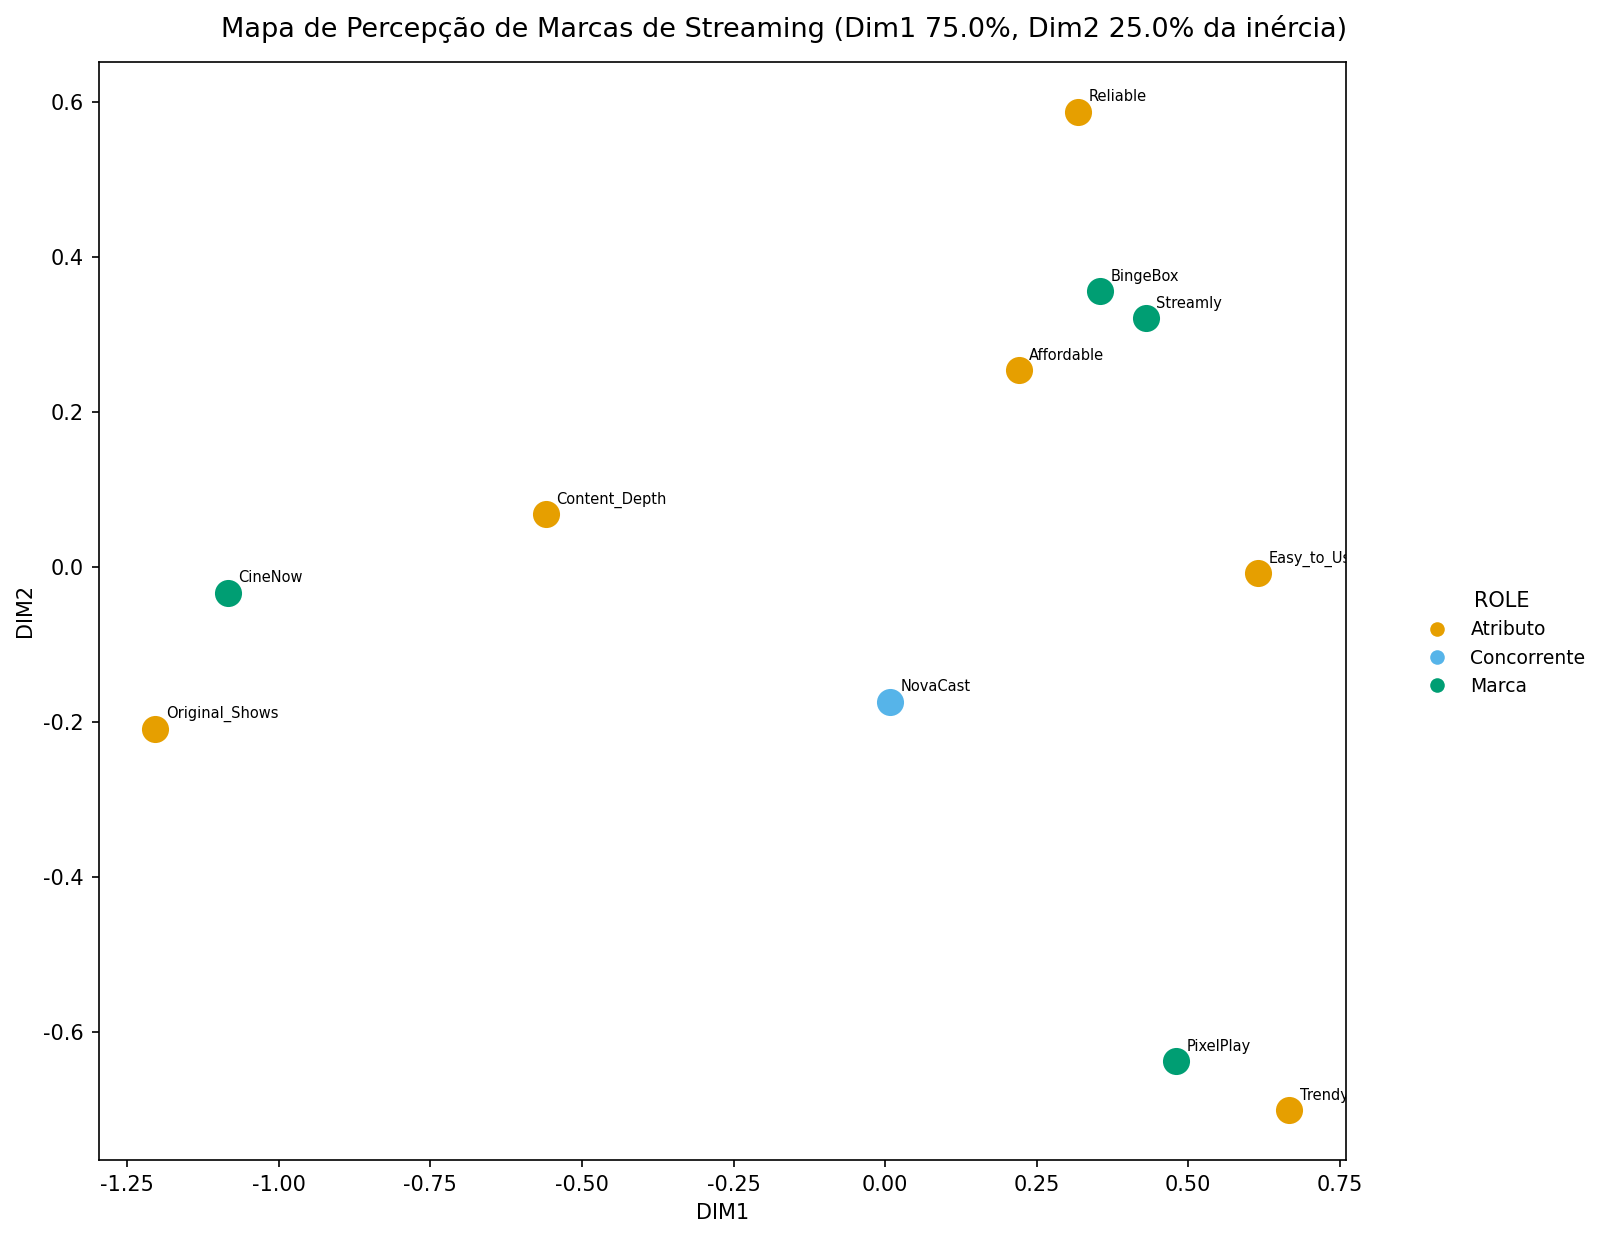

In [6]:
/* Tag each OUTC point by role for a clean, colored legend.
   Supplementary NovaCast is written to OUTC with _TYPE_='ROW',
   so we special-case it as the Challenger. */
DADOS ca_map;
    DEFINIR ca_coords_sup;
    COMPRIMENTO Role $12;
    SE _NAME_ = 'NovaCast' ENTÃO Role = 'Concorrente';
    SENÃO SE _TYPE_ = 'ROW' ENTÃO Role = 'Marca';
    SENÃO Role = 'Atributo';
    MANTER Role _NAME_ Dim1 Dim2;
EXECUTAR;

/* Set the map's title globally before the PROC so it titles this
   plot (the global TITLE drives the ODS graphic's heading). */
TÍTULO 'Mapa de Percepção de Marcas de Streaming (Dim1 75.0%, Dim2 25.0% da inércia)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP has no native ODS map in this build, so we render the
   symmetric coordinates with PROC SGSCATTER, which labels each point. */
PROCEDIMENTO SGSCATTER DADOS=ca_map;
    RÓTULO Dim1='Dimensão 1' Dim2='Dimensão 2';
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
EXECUTAR;

ODS GRAPHICS OFF;
TÍTULO;

## Interpretando os resultados

**A associação é real e totalmente capturada.** O teste qui-quadrado (63.15 com 15 gl, p < 0.0001; V de Cramer = 0.4588) rejeita a independência, e as duas dimensões da AC explicam **100%** da inércia da tabela (75.0% + 25.0%), de modo que o mapa abaixo é um resumo completo, não uma projeção com perdas.

**Três territórios perceptuais.** Lendo as coordenadas e o mapa em conjunto:

- **Conteúdo premium (esquerda).** *CineNow* (Dim1 = -1.0847) é puxado para a extrema esquerda por *Original_Shows* (-1.2037) e *Content_Depth* (-0.5594) — ele domina a percepção de profundidade de catálogo.
- **Valor e confiabilidade (superior direito).** *Streamly* (0.4304, 0.3207) e *BingeBox* (0.3547, 0.3555) agrupam-se com *Affordable* (0.2207, 0.2542) e *Reliable* (0.3183, 0.5874) — a dupla confiável e de bom custo-benefício.
- **Moderno (inferior direito).** *PixelPlay* (0.4804, -0.6374) fica ao lado de *Trendy* (0.6671, -0.7003) — a marca jovem e do momento.

**O concorrente suplementar.** Projetado sem influenciar os eixos, **NovaCast** cai em (0.0084, -0.1735) — essencialmente na origem, deslocado em direção ao lado Trendy / Easy_to_Use. Para um estrategista de mídia, essa é a manchete: o concorrente ainda não tem um valor de marca distintivo e está derivando para o território moderno da PixelPlay, de modo que um posicionamento diferenciado (em vez de um imitador) se justifica.

**Ressalvas.** A análise de correspondência é descritiva, não inferencial — as distâncias são aproximadas e os *sinais* dos eixos são arbitrários (uma inversão em espelho de qualquer eixo é o mesmo mapa). Com apenas 100 associações respondente-atributo, duas células são zero (CineNow x Easy_to_Use, Streamly x Original_Shows), o que acentua os extremos; um estudo de produção usaria uma amostra maior. Sempre combine o mapa com a tabela de inércia para confirmar quanto da associação as dimensões exibidas explicam.